<a href="https://colab.research.google.com/github/asit18/ai-ml/blob/main/colab_activity6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Self-study Colab Activity 6.2: Interpreting the Results of K-Means and PCA




In this activity, you are tasked with profiling customer groups for a large telecommunications company.  The data provided contains information on customers' purchasing and usage behavior with telecom products.  Your goal is to use PCA and clustering to segment these customers into meaningful groups, and report back your findings.  

Because these results need to be interpretable, it is important to keep the number of clusters reasonable.  Think about how you might represent some of the non-numeric features so that they can be included in your segmentation models.  You are to report back your approach and findings to the class.  Be specific about what features were used and how you interpret the resulting clusters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('sample_data/telco_churn_data.csv')

In [3]:
df.head()

,Customer ID,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,...,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
0,8779-QRDMV,No,0,1,NaN,No,0.00,No,Yes,Fiber Optic,...,34.023810,-118.156582,68701,1,5433,Competitor,Competitor offered more data,5,0,NaN
1,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Cable,...,34.044271,-118.185237,55668,1,5302,Competitor,Competitor made better offer,5,0,NaN
2,1658-BYGOY,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,...,34.108833,-118.229715,47534,1,3179,Competitor,Competitor made better offer,1,0,NaN
3,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,...,33.936291,-118.332639,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0
4,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Cable,...,33.972119,-118.020188,26265,1,2793,Price,Extra data charges,1,0,2.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Referred a Friend                  7043 non-null   object 
 2   Number of Referrals                7043 non-null   int64  
 3   Tenure in Months                   7043 non-null   int64  
 4   Offer                              3166 non-null   object 
 5   Phone Service                      7043 non-null   object 
 6   Avg Monthly Long Distance Charges  7043 non-null   float64
 7   Multiple Lines                     7043 non-null   object 
 8   Internet Service                   7043 non-null   object 
 9   Internet Type                      5517 non-null   object 
 10  Avg Monthly GB Download            7043 non-null   int64  
 11  Online Security                    7043 non-null   objec

In [5]:
numeric_cols = df.select_dtypes(include=['number']).columns
zero_variance = [col for col in numeric_cols if df[col].var() == 0]
print(zero_variance)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
skewed_categorical = [col for col in categorical_cols if df[col].value_counts(normalize=True).iloc[0] > 0.98]

print(skewed_categorical)

unique_churn_values = df['Churn Value'].unique()
print(f"Unique values in 'Churn Value': {unique_churn_values}")

# df = df[df["Churn Value"] == 1]
df = df.drop(columns=['Customer ID','Offer'])
print(df.info())
print(df[["Streaming Movies","Streaming Music"]].nunique())

[]
[]
Unique values in 'Churn Value': [1 0]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Referred a Friend                  7043 non-null   object 
 1   Number of Referrals                7043 non-null   int64  
 2   Tenure in Months                   7043 non-null   int64  
 3   Phone Service                      7043 non-null   object 
 4   Avg Monthly Long Distance Charges  7043 non-null   float64
 5   Multiple Lines                     7043 non-null   object 
 6   Internet Service                   7043 non-null   object 
 7   Internet Type                      5517 non-null   object 
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Online Security                    7043 non-null   object 
 10  Online Backup                      7043 non-null   object 
 11  Device Prote

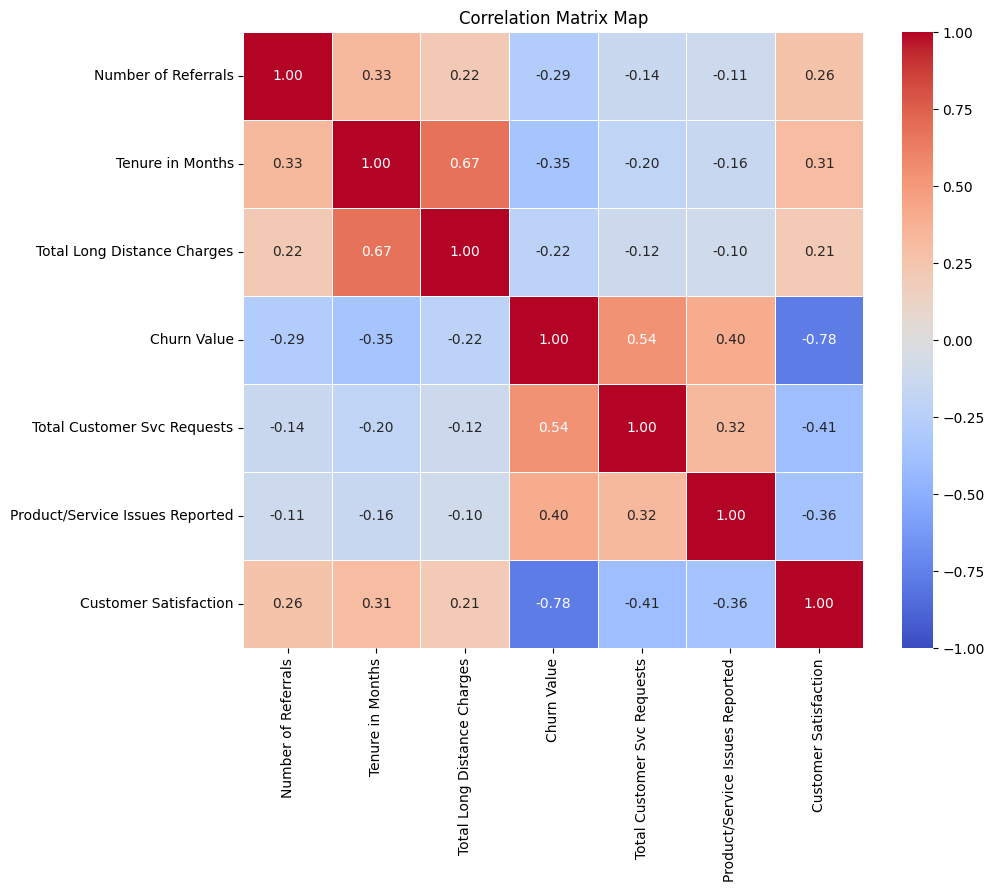

In [6]:
# df = df[df["Churn Value"] == 1]
df = df.drop(columns=['Zip Code', 'Latitude', 'Longitude', 'Total Regular Charges',
                      'Population', 'Avg Monthly GB Download','Total Refunds',
                      'Avg Monthly Long Distance Charges','CLTV','Total Extra Data Charges',
                      'Monthly Charge', 'Age', 'Number of Dependents'])
df.head()
corr_matrix = df.corr(numeric_only=True)
filtered_corr = corr_matrix[corr_matrix.abs() > 0.3]
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Shows the correlation numbers inside the squares
    cmap="coolwarm",  # Red for positive correlation, blue for negative
    fmt=".2f",  # Limits decimals to 2 places
    vmin=-1,
    vmax=1,  # Sets the colorbar scale limits
    linewidths=0.5,  # Adds thin borders between squares
)
plt.title("Correlation Matrix Map")
plt.show()

In [7]:
#encode non-numerical features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# df['Gender', 'Phone Service'] = le.fit_transform(df[columns=['Gender', 'Phone Service']])

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df.info()
df.head()

correlation_matrix = df.corr(numeric_only=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Referred a Friend                7043 non-null   int64  
 1   Number of Referrals              7043 non-null   int64  
 2   Tenure in Months                 7043 non-null   int64  
 3   Phone Service                    7043 non-null   int64  
 4   Multiple Lines                   7043 non-null   int64  
 5   Internet Service                 7043 non-null   int64  
 6   Internet Type                    7043 non-null   int64  
 7   Online Security                  7043 non-null   int64  
 8   Online Backup                    7043 non-null   int64  
 9   Device Protection Plan           7043 non-null   int64  
 10  Premium Tech Support             7043 non-null   int64  
 11  Streaming TV                     7043 non-null   int64  
 12  Streaming Movies    

In [8]:
df.query("`Customer Satisfaction` in (4,5)").head()
# print(df['Customer Satisfaction'].unique().tolist())

,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,...,Senior Citizen,Married,Dependents,City,Churn Value,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
477,1,10,2,1,0,1,2,0,0,1,...,1,1,0,554,0,5,20,1,0,5.0
483,1,9,64,1,1,1,2,1,0,1,...,1,1,0,267,0,5,20,1,0,4.0
493,0,0,13,1,0,1,2,0,1,1,...,1,0,0,187,0,5,20,1,1,4.0
510,0,0,7,1,0,1,2,0,0,0,...,1,0,0,854,0,5,20,1,0,5.0
518,1,9,32,1,0,1,2,0,1,0,...,1,1,1,638,0,5,20,2,0,5.0


In [9]:
df.groupby(["Churn Category", "Churn Reason","Customer Satisfaction"]).count()

Referred a Friend  \
Churn Category Churn Reason Customer Satisfaction                      
0              0            1.0                                   11   
                            2.0                                   14   
                            3.0                                   13   
               1            1.0                                   26   
                            2.0                                   31   
                            3.0                                   28   
1              2            1.0                                  110   
                            2.0                                    2   
               3            1.0                                   49   
                            2.0                                   34   
                            3.0                                   27   
               4            1.0                                   20   
                            2.0                                   14   
                            3.0                                    8   
               5            1.0                                   11   
                            2.0                                   11   
                            3.0                                    9   
2              10           1.0                                    5   
                            2.0                                    6   
                            3.0                                    2   
               11           1.0                                    4   
                            2.0                                    7   
                            3.0                                    3   
               14           1.0                                   13   
                            2.0                                    5   
                            3.0                                   15   
               15           2.0                                    4   
                            3.0                                    1   
               16           1.0                                    2   
                            2.0                                    1   
                            3.0                                    2   
               18           1.0                                   19   
                            2.0                                    3   
               19           1.0                                    9   
                            2.0                                    9   
                            3.0                                    4   
3              6            1.0                                    1   
                            3.0                                    1   
               7            1.0                                   17   
                            2.0                                   22   
                            3.0                                    6   
               13           1.0                                    2   
                            2.0                                    7   
                            3.0                                    9   
               15           3.0                                    6   
4              8            1.0                                    6   
                            2.0                                    6   
                            3.0                                    3   
               9            1.0                                    5   
                            2.0                                    4   
               12           1.0                                   11   
                            2.0                                   10   
                            3.0                                    4   
               17           1.0                                   11   
                   

In [10]:
df["Customer Satisfaction"].value_counts()

,count
Customer Satisfaction,
3.0,675
4.0,380
1.0,332
5.0,247
2.0,200


In [11]:
df.groupby(["Customer Satisfaction"]).count()

print(df["Customer Satisfaction"].isna().sum())

5209


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Referred a Friend                7043 non-null   int64  
 1   Number of Referrals              7043 non-null   int64  
 2   Tenure in Months                 7043 non-null   int64  
 3   Phone Service                    7043 non-null   int64  
 4   Multiple Lines                   7043 non-null   int64  
 5   Internet Service                 7043 non-null   int64  
 6   Internet Type                    7043 non-null   int64  
 7   Online Security                  7043 non-null   int64  
 8   Online Backup                    7043 non-null   int64  
 9   Device Protection Plan           7043 non-null   int64  
 10  Premium Tech Support             7043 non-null   int64  
 11  Streaming TV                     7043 non-null   int64  
 12  Streaming Movies    

In [13]:
df.describe()

,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,...,Senior Citizen,Married,Dependents,City,Churn Value,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,1834.000000
mean,0.457476,1.951867,32.386767,0.903166,0.421837,0.783331,1.539117,0.286668,0.344881,0.343888,...,0.162147,0.483033,0.231010,588.042879,0.265370,4.083629,16.386341,1.338776,0.308107,3.005453
std,0.498224,3.001199,24.542061,0.295752,0.493888,0.412004,1.058766,0.452237,0.475363,0.475038,...,0.368612,0.499748,0.421508,307.797647,0.441561,1.648187,6.715036,1.430471,0.717514,1.256938
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,9.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,331.000000,0.000000,4.000000,18.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,29.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,604.000000,0.000000,5.000000,20.000000,1.000000,0.000000,3.000000
75%,1.000000,3.000000,55.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,854.000000,1.000000,5.000000,20.000000,2.000000,0.000000,4.000000
max,1.000000,11.000000,72.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1105.000000,1.000000,5.000000,20.000000,9.000000,6.000000,5.000000


In [14]:
# df = pd.read_csv('sample_data/telco_churn_data.csv') # Reload the original data

# # Calculate the median of 'Customer Satisfaction' before imputation
# median_satisfaction = df['Customer Satisfaction'].median()

# # Impute missing 'Customer Satisfaction' values with the median
# df['Customer Satisfaction'] = df['Customer Satisfaction'].fillna(median_satisfaction)

# df.head()
# df.describe()

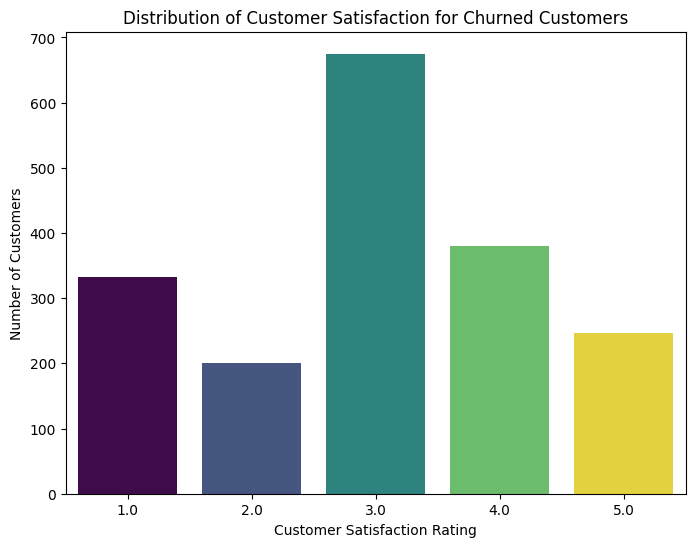

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Satisfaction', hue='Customer Satisfaction', data=df, palette='viridis', legend=False)
plt.title('Distribution of Customer Satisfaction for Churned Customers')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.show()

To understand the relationship between churn category and total churn, we'll first filter the DataFrame to include only customers who have churned (`Churn Value == 1`). Then, we'll group these churned customers by their `Churn Category` and count how many fall into each category. This will show us the primary reasons why customers are churning.

In [16]:
# Filter for churned customers
churned_customers = df[df['Churn Value'] == 1]

# Group by 'Churn Category' and count the number of churned customers in each category
churn_category_counts = churned_customers['Churn Category'].value_counts().reset_index()
churn_category_counts.columns = ['Churn Category', 'Total Churn']

# Display the results
display(churn_category_counts)

,Churn Category,Total Churn
0,1,841
1,0,314
2,2,303
3,4,211
4,3,200


Now, let's visualize this distribution to easily compare the impact of different churn categories.

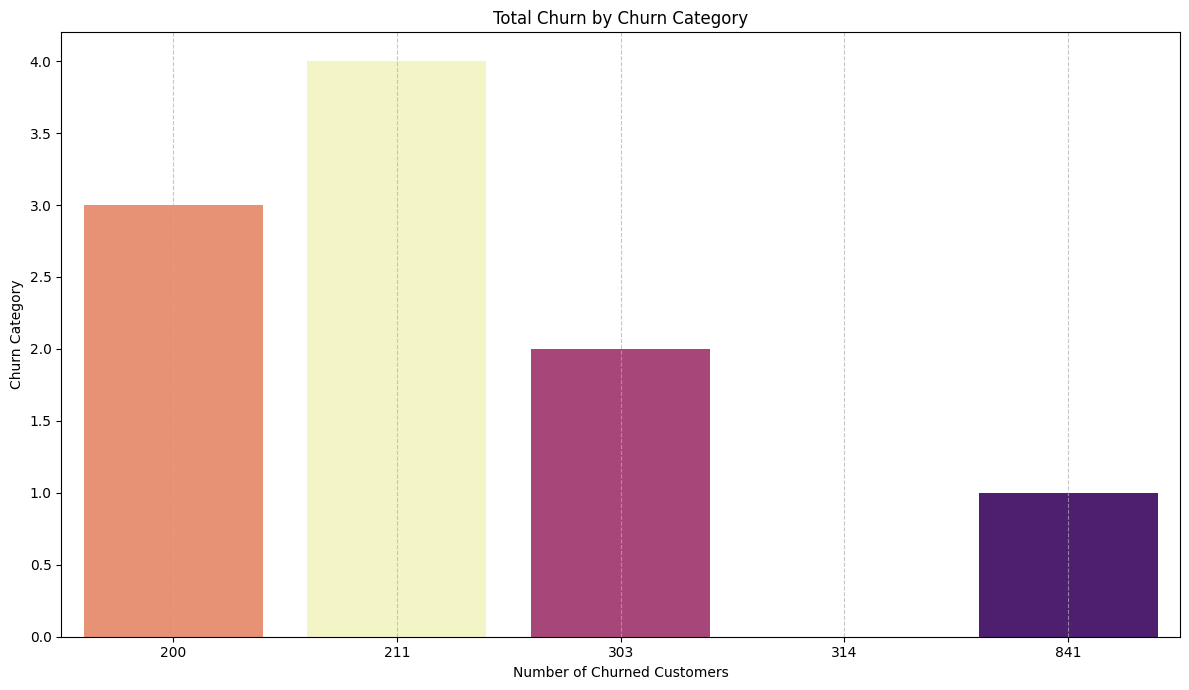

In [17]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Total Churn', y='Churn Category', hue='Churn Category', data=churn_category_counts, palette='magma', legend=False)
plt.title('Total Churn by Churn Category')
plt.xlabel('Number of Churned Customers')
plt.ylabel('Churn Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now, let's look at the percentage distribution of 'Churn Reason' within each 'Churn Category'. This will help us understand the most common specific reasons for churn within each broader category.

In [18]:
# Ensure 'churned_customers' DataFrame is available from previous steps
# If not, recreate it:
# churned_customers = df[df['Churn Value'] == 1]

# Calculate the percentage of each 'Churn Reason' within its 'Churn Category'
churn_reason_percentages = churned_customers.groupby('Churn Category')['Churn Reason'].value_counts(normalize=True) * 100
churn_reason_percentages = churn_reason_percentages.unstack().fillna(0)

display(churn_reason_percentages)

Churn Reason,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Churn Category,,,,,,,,,,,,,,,,,,,,
0,29.936306,70.063694,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,37.217598,36.979786,11.890606,13.91201,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,9.570957,12.211221,0.000000,0.0,23.762376,4.290429,3.960396,0.000000,25.412541,20.792079
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.0,65.0,0.000000,0.000000,0.000000,0.000000,0.000000,23.0,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,18.483412,14.218009,0.000000,0.000000,30.331754,0.0,0.000000,0.000000,0.000000,36.966825,0.000000,0.000000


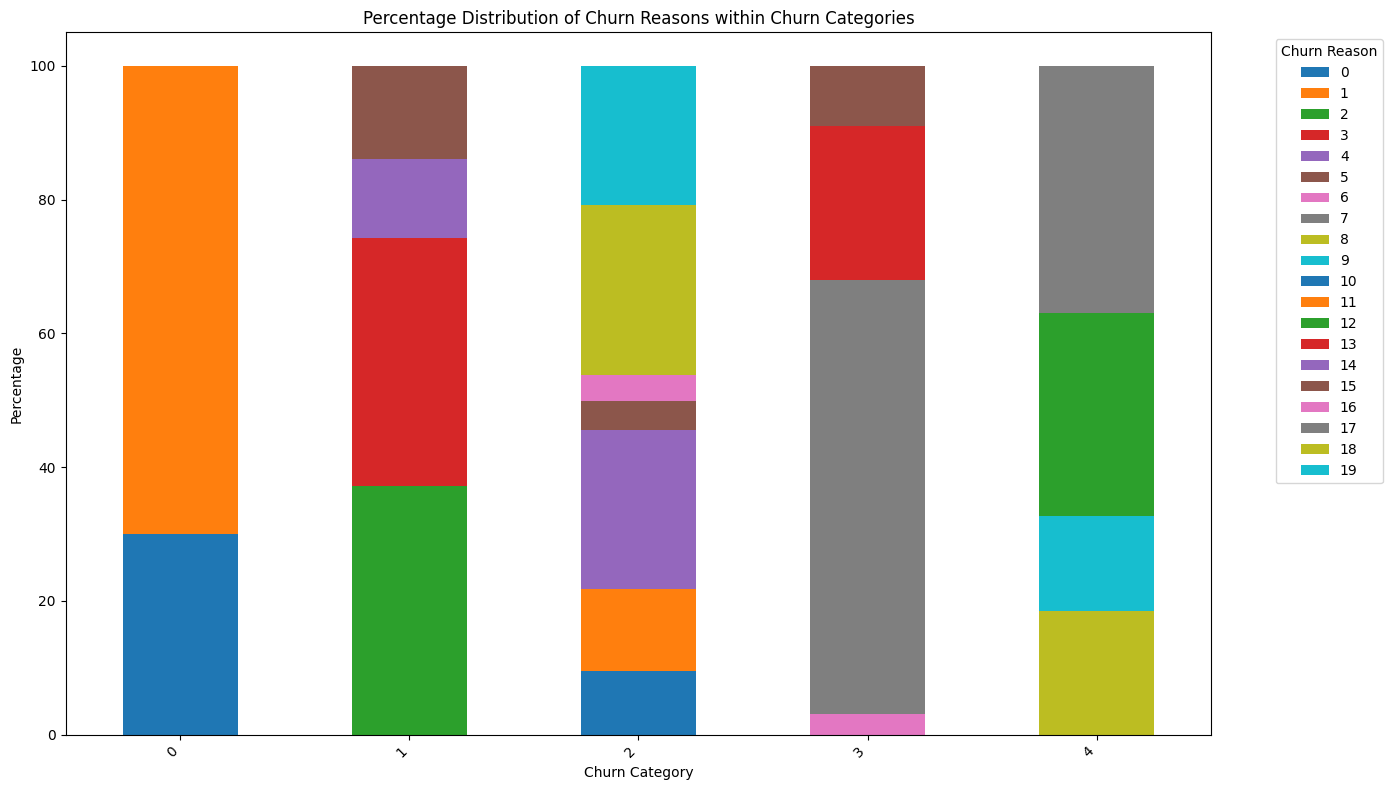

In [19]:
import matplotlib.pyplot as plt

# Plotting the stacked bar chart
ax = churn_reason_percentages.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Percentage Distribution of Churn Reasons within Churn Categories')
plt.xlabel('Churn Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Let's calculate the correlation between 'Total Customer Svc Requests' and 'Churn Value' to see if there's a relationship between the number of service requests and customer churn.

In [20]:
correlation = df['Total Customer Svc Requests'].corr(df['Churn Value'])
print(f"Correlation between 'Total Customer Svc Requests' and 'Churn Value': {correlation:.2f}")

Correlation between 'Total Customer Svc Requests' and 'Churn Value': 0.54


A box plot can visually represent the distribution of 'Total Customer Svc Requests' for each 'Churn Value', helping us understand if there's a noticeable difference between churned and non-churned customers.

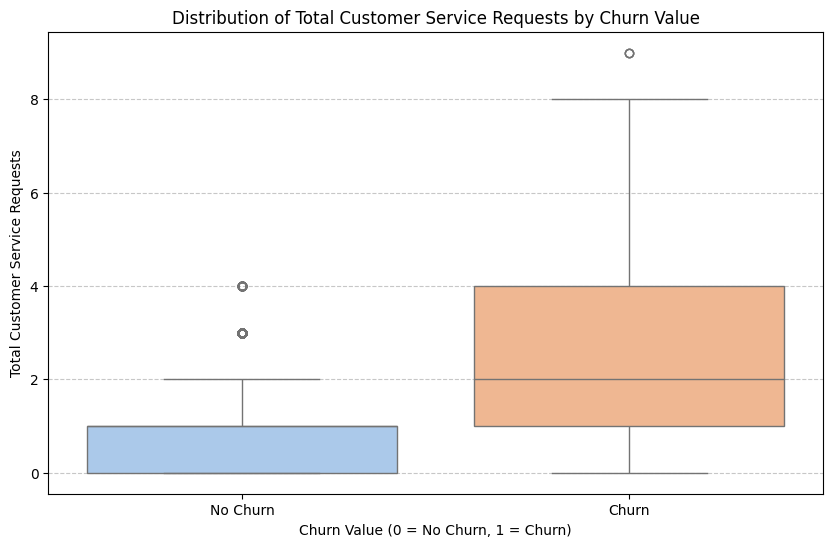

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn Value', y='Total Customer Svc Requests', data=df, palette='pastel', hue='Churn Value', legend=False)
plt.title('Distribution of Total Customer Service Requests by Churn Value')
plt.xlabel('Churn Value (0 = No Churn, 1 = Churn)')
plt.ylabel('Total Customer Service Requests')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
df.head()
print(df.info())
features_numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
features_non_numeric = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
print(features_numeric_cols)
print(features_non_numeric)
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Drop columns with too many NaNs before scaling
df_clean = df.dropna()
print(df.head())
scaled = StandardScaler()
df_scaled = scaled.fit_transform(df_clean)
pca = PCA(n_components=5)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca)
df_pca.head()
print(pca.explained_variance_ratio_)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Referred a Friend                7043 non-null   int64  
 1   Number of Referrals              7043 non-null   int64  
 2   Tenure in Months                 7043 non-null   int64  
 3   Phone Service                    7043 non-null   int64  
 4   Multiple Lines                   7043 non-null   int64  
 5   Internet Service                 7043 non-null   int64  
 6   Internet Type                    7043 non-null   int64  
 7   Online Security                  7043 non-null   int64  
 8   Online Backup                    7043 non-null   int64  
 9   Device Protection Plan           7043 non-null   int64  
 10  Premium Tech Support             7043 non-null   int64  
 11  Streaming TV                     7043 non-null   int64  
 12  Streaming Movies    

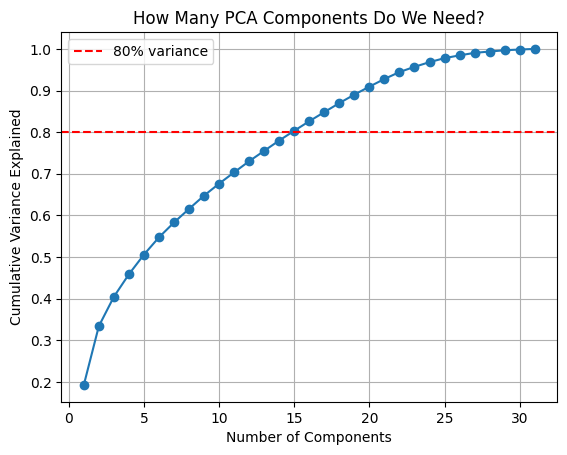

In [23]:
pca_full = PCA()
pca_full.fit(df_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('How Many PCA Components Do We Need?')
plt.legend()
plt.grid(True)
plt.show()

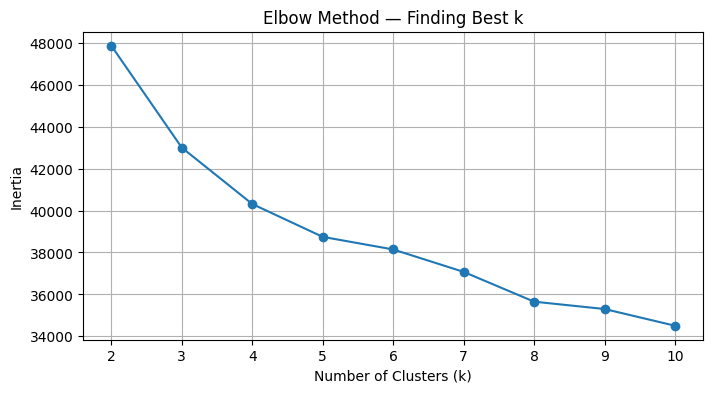

In [24]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best k')
plt.grid(True)
plt.show()

[0.19253967 0.14130734]
Total variance captured: 33.38%


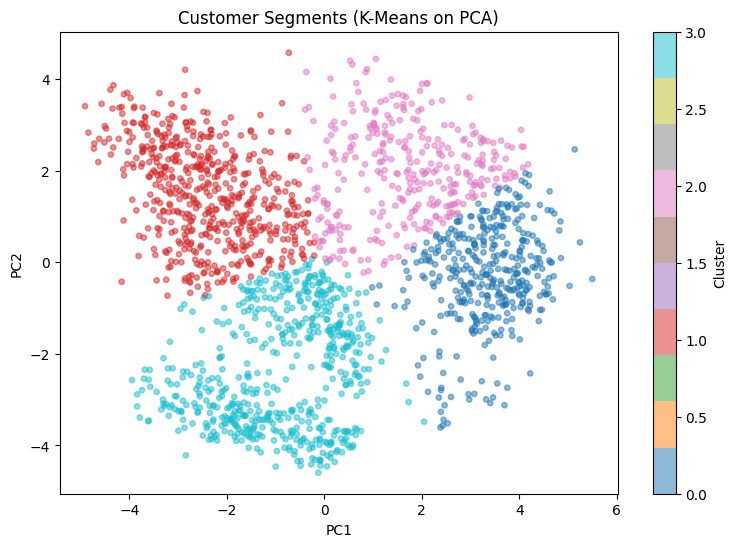

In [25]:
# Apply PCA first (reduces noise, speeds up clustering)
pca = PCA(n_components=2)  # 2 components so we can visualize
df_pca = pca.fit_transform(df_scaled)

# Run K-Means (let's say elbow said k=4)
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = km.fit_predict(df_pca)

print(pca.explained_variance_ratio_)
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")

# Visualize clusters
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (K-Means on PCA)')
plt.show()

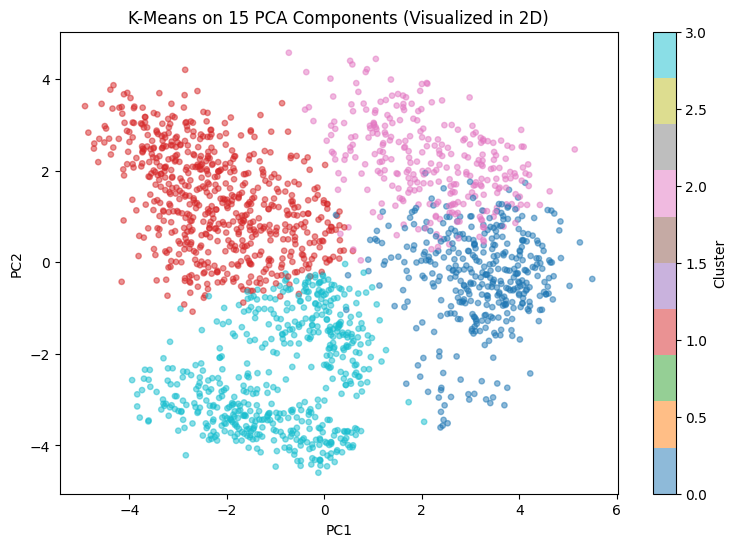

In [26]:
# Use 15 components instead of 2
pca_15 = PCA(n_components=15)
df_pca_15 = pca_15.fit_transform(df_scaled)

# Cluster in 15D (better separation)
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = km.fit_predict(df_pca_15)

# But still VISUALIZE in 2D
pca_2 = PCA(n_components=2)
df_pca_2 = pca_2.fit_transform(df_pca_15)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_pca_2[:, 0], df_pca_2[:, 1],
                      c=labels, cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means on 15 PCA Components (Visualized in 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

# Try different k values
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(df_pca_15)
    score = silhouette_score(df_pca_15, labels)
    print(f"k={k} → silhouette score: {score:.3f}")

k=2 → silhouette score: 0.190
k=3 → silhouette score: 0.184
k=4 → silhouette score: 0.149
k=5 → silhouette score: 0.156
k=6 → silhouette score: 0.149
k=7 → silhouette score: 0.141


In [28]:
# Compare inertia of both approaches
km_2d = KMeans(n_clusters=4, random_state=42, n_init='auto')
km_2d.fit(df_pca_2)  # your 2 component version

km_15d = KMeans(n_clusters=4, random_state=42, n_init='auto')
km_15d.fit(df_pca_15)  # your 15 component version

print(f"Inertia with 2 PCA components:  {km_2d.inertia_:.0f}")
print(f"Inertia with 15 PCA components: {km_15d.inertia_:.0f}")

Inertia with 2 PCA components:  4288
Inertia with 15 PCA components: 30307


In [29]:
from sklearn.metrics import silhouette_score

score_2d = silhouette_score(df_pca_2, km_2d.labels_)
score_15d = silhouette_score(df_pca_15, km_15d.labels_)

print(f"Silhouette score 2D:  {score_2d:.3f}")
print(f"Silhouette score 15D: {score_15d:.3f}")

Silhouette score 2D:  0.443
Silhouette score 15D: 0.149


In [30]:
df_clean['Cluster'] = labels

# Look at the mean of each feature per cluster
df_clean.groupby('Cluster').mean(numeric_only=True).T

/tmp/ipykernel_811/3451527295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = labels


Cluster,0,1,2,3,4,5,6
Referred a Friend,0.155844,0.863436,0.383333,0.506536,0.168342,0.677165,0.137681
Number of Referrals,0.238095,4.559471,0.577778,2.460784,0.723618,1.236220,0.239130
Tenure in Months,7.142857,54.707048,15.488889,33.535948,24.917085,44.889764,12.333333
Phone Service,0.852814,0.907489,0.961111,1.000000,0.816583,0.952756,0.891304
Multiple Lines,0.151515,0.592511,0.666667,0.225490,0.311558,0.795276,0.434783
Internet Service,0.861472,1.000000,1.000000,0.019608,1.000000,1.000000,1.000000
Internet Type,1.220779,1.343612,0.666667,2.977124,1.276382,0.669291,0.869565
Online Security,0.142857,0.616740,0.088889,0.000000,0.331658,0.314961,0.123188
Online Backup,0.164502,0.647577,0.305556,0.003268,0.346734,0.582677,0.202899
Device Protection Plan,0.082251,0.680617,0.277778,0.000000,0.311558,0.732283,0.260870


In [31]:
loadings = pd.DataFrame(
    pca.components_.T,  # transpose so features are rows
    index=df_clean.drop(columns=['Cluster']).columns,  # Exclude the 'Cluster' column as it was added after PCA fitting
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Show features that contribute most to PC1 and PC2
print("=== Top contributors to PC1 ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(8))

print("\n=== Top contributors to PC2 ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(8))

=== Top contributors to PC1 ===
Churn Value              0.348422
Churn Category           0.338252
Churn Reason             0.330797
Tenure in Months         0.285649
Customer Satisfaction    0.282939
Contract                 0.279697
Number of Referrals      0.237785
Married                  0.216406
Name: PC1, dtype: float64

=== Top contributors to PC2 ===
Internet Service          0.357803
Streaming Movies          0.348561
Streaming TV              0.317799
Streaming Music           0.315222
Internet Type             0.292072
Device Protection Plan    0.271082
Online Backup             0.227086
Premium Tech Support      0.202002
Name: PC2, dtype: float64


In [32]:
for eps in [0.3, 0.5, 0.8, 1.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = db.fit_predict(df_pca)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    print(f"eps={eps} → clusters={n_clusters}, noise={n_noise}")

eps=0.3 → clusters=6, noise=312
eps=0.5 → clusters=2, noise=45
eps=0.8 → clusters=1, noise=2
eps=1.0 → clusters=1, noise=2


Clusters found: 3
Noise points: 127


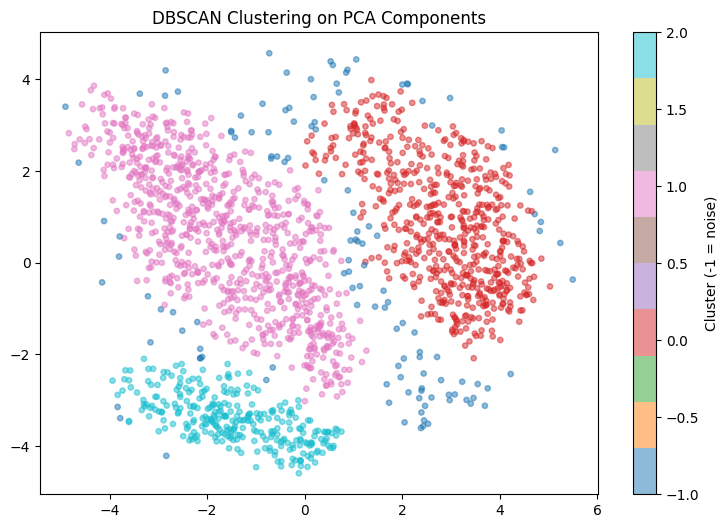

In [33]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=10)
db_labels = db.fit_predict(df_pca)  # -1 means noise/outlier

# How many clusters did it find?
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

# Visualize
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=db_labels, cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.title('DBSCAN Clustering on PCA Components')
plt.show()

In [34]:
df_clean['DBSCAN_Cluster'] = db_labels
df_clean.groupby('DBSCAN_Cluster').mean(numeric_only=True).T

/tmp/ipykernel_811/2565020302.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DBSCAN_Cluster'] = db_labels


DBSCAN_Cluster,-1,0,1,2
Referred a Friend,0.496063,0.284483,0.542413,0.489655
Number of Referrals,1.740157,0.456897,2.728793,2.379310
Tenure in Months,31.748031,16.291379,40.281959,33.310345
Phone Service,0.976378,0.900000,0.862605,0.996552
Multiple Lines,0.496063,0.470690,0.455197,0.210345
Internet Service,0.685039,1.000000,0.994026,0.010345
Internet Type,1.551181,0.791379,1.330944,2.986207
Online Security,0.251969,0.148276,0.477897,0.000000
Online Backup,0.362205,0.284483,0.498208,0.000000
Device Protection Plan,0.409449,0.275862,0.500597,0.000000
